### Exercise 2 - Overlapping Data: The Aase The Perceptron Cannot Solve

A - Generate the Data

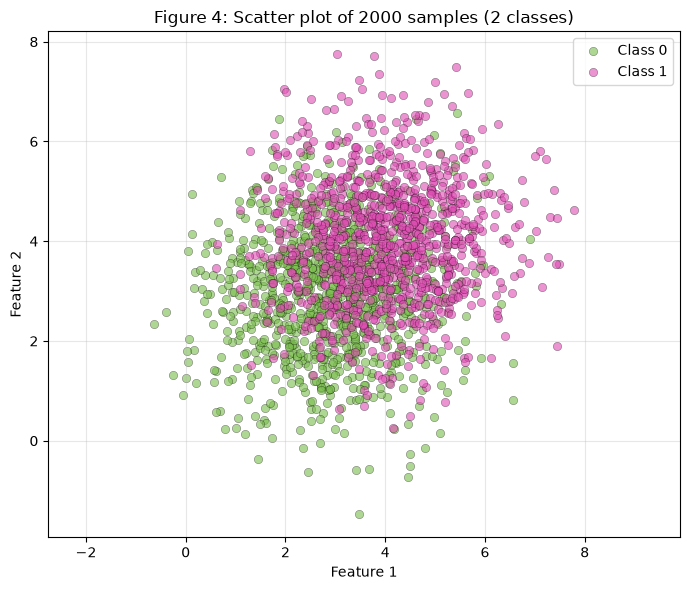

In [4]:
import numpy as np
import matplotlib.pyplot as plt

params = {
    0: {
        "mean": np.array([3.0, 3.0]), 
        "cov": np.array([
            [1.5, 0.0],
            [0.0, 1.5]
        ])
    },
    1: {
        "mean": np.array([4.0, 4.0]), 
        "cov": np.array([
            [1.5, 0.0],
            [0.0, 1.5]
        ])
    }
}

n_per_class = 1000
rng = np.random.default_rng(seed=42)

class_0 = rng.multivariate_normal(
    mean=params[0]["mean"],
    cov=params[0]["cov"],
    size=n_per_class,
)

class_1 = rng.multivariate_normal(
    mean=params[1]["mean"],
    cov=params[1]["cov"],
    size=n_per_class,
)

colors = ["#79bd4c", "#e04db4"]
plt.figure(figsize=(7, 6))

plt.scatter(class_0[:, 0], class_0[:, 1], c=colors[0], label="Class 0", alpha=0.6, edgecolors="k", linewidths=0.3)
plt.scatter(class_1[:, 0], class_1[:, 1], c=colors[1], label="Class 1", alpha=0.6, edgecolors="k", linewidths=0.3)

plt.title("Figure 4: Scatter plot of 2000 samples (2 classes)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/figure4.png", dpi=150)
plt.show()

B - Train, keeping the best weights

In [5]:
class Perceptron:
    def __init__(self, n_features, eta=0.01, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.eta = eta

    def step(self, z):
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        z = X @ self.w + self.b
        return self.step(z)

    def fit(self, X, y, max_epochs=100):
        accuracy_history = []

        for epoch in range(max_epochs):
            updated = False

            for xi, yi in zip(X, y):
                y_hat = self.step(xi @ self.w + self.b)
                error = yi - y_hat

                if error != 0:
                    self.w += self.eta * error * xi
                    self.b += self.eta * error
                    updated = True

            # accuracy on the full dataset after this epoch
            y_pred = self.predict(X)
            acc = np.mean(y_pred == y)
            accuracy_history.append(acc)

            if not updated:
                break

        return accuracy_history

In [9]:
class PerceptronPocket(Perceptron):
    def fit(self, X, y, max_epochs=100):
        accuracy_history = []
        pocket_accuracy_history = []  # best-so-far, recorded once per epoch

        pocket_w = self.w.copy()
        pocket_b = self.b
        pocket_acc = np.mean(self.predict(X) == y)

        for epoch in range(max_epochs):
            updated = False

            for xi, yi in zip(X, y):
                y_hat = self.step(xi @ self.w + self.b)
                error = yi - y_hat

                if error != 0:
                    self.w += self.eta * error * xi
                    self.b += self.eta * error
                    updated = True

                    acc_now = np.mean(self.predict(X) == y)
                    if acc_now > pocket_acc:
                        pocket_acc = acc_now
                        pocket_w = self.w.copy()
                        pocket_b = self.b

            acc = np.mean(self.predict(X) == y)
            accuracy_history.append(acc)
            pocket_accuracy_history.append(pocket_acc)  # best-so-far after this epoch

            if not updated:
                break

        self.pocket_w = pocket_w
        self.pocket_b = pocket_b
        self.pocket_acc = pocket_acc
        self.pocket_accuracy_history = pocket_accuracy_history

        return accuracy_history

In [10]:
X = np.vstack([class_0, class_1])
y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])

rng_train = np.random.default_rng(seed=42)
model = PerceptronPocket(n_features=2, eta=0.01, rng=rng_train)
acc_history = model.fit(X, y, max_epochs=100)

final_acc = acc_history[-1]

print("=== Final weights ===")
print(f"w = {model.w}")
print(f"b = {model.b:.4f}")
print(f"accuracy = {final_acc:.4f}")

print("\n=== Pocket weights ===")
print(f"w = {model.pocket_w}")
print(f"b = {model.pocket_b:.4f}")
print(f"accuracy = {model.pocket_acc:.4f}")

=== Final weights ===
w = [0.04132471 0.04149595]
b = -0.0400
accuracy = 0.5005

=== Pocket weights ===
w = [0.00638225 0.00545806]
b = -0.0400
accuracy = 0.7285


C - Figures

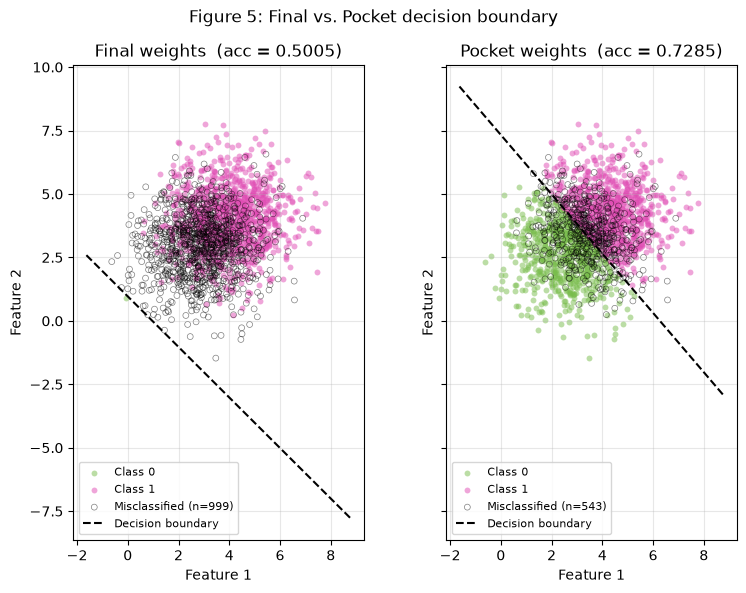

In [21]:
def plot_boundary_line(w, b, x1_range, ax, **kwargs):
    w1, w2 = w
    if w2 != 0:
        x2_range = -(w1 * x1_range + b) / w2
        ax.plot(x1_range, x2_range, **kwargs)
    else:
        x_vert = -b / w1
        ax.axvline(x_vert, **kwargs)

y_pred_final = model.predict(X)
y_pred_pocket = np.where(X @ model.pocket_w + model.pocket_b >= 0, 1, 0)

miscls_final = y_pred_final != y
miscls_pocket = y_pred_pocket != y

fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharex=True, sharey=True)
x1_range = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])

for ax, w, b, miscls, title in [
    (axes[0], model.w, model.b, miscls_final, "Final weights"),
    (axes[1], model.pocket_w, model.pocket_b, miscls_pocket, "Pocket weights"),
]:
    # correctly classified: normal markers, class color
    ax.scatter(X[(y == 0) & ~miscls, 0], X[(y == 0) & ~miscls, 1],
               c=colors[0], alpha=0.5, s=18, linewidths=0, label="Class 0")
    ax.scatter(X[(y == 1) & ~miscls, 0], X[(y == 1) & ~miscls, 1],
               c=colors[1], alpha=0.5, s=18, linewidths=0, label="Class 1")

    # misclassified: small, thin, semi-transparent, no fill
    ax.scatter(X[miscls, 0], X[miscls, 1],
               facecolors="none", edgecolors="black", marker="o", s=18,
               linewidths=0.5, alpha=0.5, label=f"Misclassified (n={miscls.sum()})")

    plot_boundary_line(w, b, x1_range, ax, color="k", linestyle="--",
                        linewidth=1.5, label="Decision boundary")

    ax.set_title(f"{title}  (acc = {np.mean(~miscls):.4f})")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_aspect("equal")

fig.suptitle("Figure 5: Final vs. Pocket decision boundary")
plt.tight_layout()
plt.savefig("./figures/figure5.png", dpi=150)
plt.show()

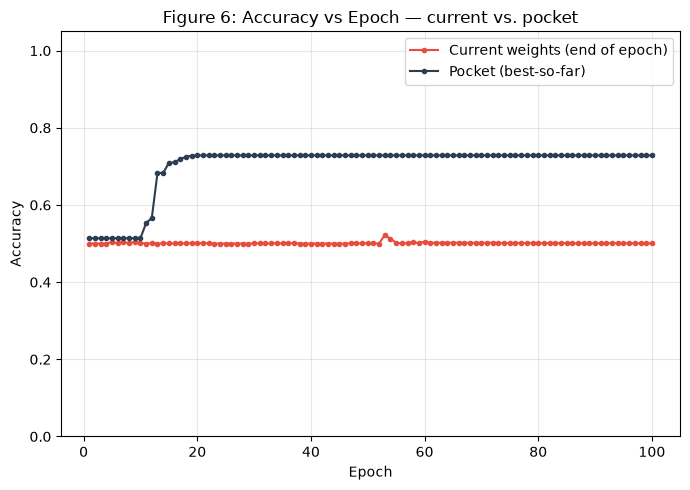

In [19]:
epochs = range(1, len(acc_history) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, acc_history, color="#e74c3c", marker="o", markersize=3,
          label="Current weights (end of epoch)")
plt.plot(epochs, model.pocket_accuracy_history, color="#2c3e50", marker="o", markersize=3,
          label="Pocket (best-so-far)")

plt.title("Figure 6: Accuracy vs Epoch — current vs. pocket")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/figure6.png", dpi=150)
plt.show()

D - Analysis